<a href="https://colab.research.google.com/github/Joker-Bat/offline_plant_doctor/blob/develop/01_model_training/02_Vision_Model_Training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# --- Part A: Environment Setup ---
import os
from google.colab import files

# 1. Configure Kaggle API
# We check if the file already exists to avoid re-uploading every time.
if not os.path.exists("/root/.kaggle/kaggle.json"):
    print("Please upload your kaggle.json file")
    uploaded = files.upload()
    !mkdir -p ~/.kaggle
    !mv kaggle.json ~/.kaggle/
    !chmod 600 ~/.kaggle/kaggle.json
    print("\nKaggle API key configured.")
else:
    print("Kaggle API key already exists.")

# 2. Download and Unzip Data
data_dir = "data"
# We check if the directory exists to avoid re-downloading.
if not os.path.exists(data_dir):
    dataset_name = "vipoooool/new-plant-diseases-dataset"
    print(f"\nDownloading dataset '{dataset_name}' from Kaggle...")
    !kaggle datasets download -d {dataset_name} -p {data_dir} --unzip
    print("\nDownload and extraction complete.")
else:
    print("\nDataset already downloaded and unzipped.")

Kaggle API key already exists.

Dataset already downloaded and unzipped.


In [2]:
# --- Part B (Corrected for RAM): Data Preparation for TensorFlow ---
import tensorflow as tf
import os

# 1. Define Hyperparameters and Paths (This is all the same)
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = 38
EPOCHS = 5
base_dataset_dir = os.path.join('data', 'New Plant Diseases Dataset(Augmented)', 'New Plant Diseases Dataset(Augmented)')
train_dir = os.path.join(base_dataset_dir, 'train')
validation_dir = os.path.join(base_dataset_dir, 'valid')

# 2. Load Data into TensorFlow Datasets (This is all the same)
print("Loading and preparing image data...")
train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir, labels='inferred', label_mode='categorical',
    image_size=IMG_SIZE, interpolation='nearest', batch_size=BATCH_SIZE, shuffle=True
)
validation_dataset = tf.keras.utils.image_dataset_from_directory(
    validation_dir, labels='inferred', label_mode='categorical',
    image_size=IMG_SIZE, interpolation='nearest', batch_size=BATCH_SIZE, shuffle=False
)

# 3. Configure dataset for performance WITHOUT CACHING
# We REMOVED .cache() from these lines to prevent RAM overload.
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
validation_dataset = validation_dataset.prefetch(buffer_size=AUTOTUNE)

print("\n✅ Datasets are now configured for streaming and ready for training.")

Loading and preparing image data...
Found 70295 files belonging to 38 classes.
Found 17572 files belonging to 38 classes.

✅ Datasets are now configured for streaming and ready for training.


In [3]:
# --- Part C (Final Version): Build, Compile, and Train the Model using Keras Applications ---
import tensorflow as tf

# 1. Define the Model Architecture using the native Keras MobileNetV3
print("Defining the model architecture using native Keras MobileNetV3Small...")

# --- Keras Applications Model Definition ---

# Define the input layer with the shape of our images
inputs = tf.keras.Input(shape=IMG_SIZE + (3,))

# Load the MobileNetV3 model from Keras Applications.
# - include_top=False: This is crucial. It removes the final 1000-class ImageNet classifier.
# - weights='imagenet': This downloads the weights pre-trained on the ImageNet dataset.
base_model = tf.keras.applications.MobileNetV3Small(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights='imagenet'
)

# Freeze the base model so we only train our new layers
base_model.trainable = False

# Pass the inputs through the base model
x = base_model(inputs, training=False)

# To transition from the convolutional base to the dense classifier,
# we need to flatten the feature maps. GlobalAveragePooling2D is the best way to do this.
x = tf.keras.layers.GlobalAveragePooling2D()(x)

# Add a dropout layer for regularization to prevent overfitting
x = tf.keras.layers.Dropout(0.2)(x)

# Add our final classification layer with softmax activation
outputs = tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')(x)

# Create the final model
model = tf.keras.Model(inputs, outputs)

# --- End of Keras Applications Model Definition ---


# Display the model's structure.
print("\nModel Summary:")
model.summary()

# 2. Compile the Model (This part remains the same)
print("\nCompiling the model...")
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 3. Train the Model (This part remains the same)
print("\nStarting model training...")
history = model.fit(
    train_dataset,
    epochs=EPOCHS,
    validation_data=validation_dataset
)

print("\n✅ Model training complete.")

Defining the model architecture using native Keras MobileNetV3Small...

Model Summary:


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Small (Functional)   │ (None, 7, 7, 576)      │       939,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 576)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 38)             │        21,926 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 961,046 (3.67 MB)

 Trainable params: 21,926 (85.65 KB)

 Non-trainable params: 939,120 (3.58 MB)


Compiling the model...

Starting model training...
Epoch 1/5
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 168s 70ms/step - accuracy: 0.7269 - loss: 1.1171 - val_accuracy: 0.9469 - val_loss: 0.2078
Epoch 2/5
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 137s 62ms/step - accuracy: 0.9389 - loss: 0.2198 - val_accuracy: 0.9619 - val_loss: 0.1378
Epoch 3/5
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 118s 54ms/step - accuracy: 0.9499 - loss: 0.1673 - val_accuracy: 0.9667 - val_loss: 0.1126
Epoch 4/5
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 117s 53ms/step - accuracy: 0.9566 - loss: 0.1424 - val_accuracy: 0.9681 - val_loss: 0.1040
Epoch 5/5
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 117s 53ms/step - accuracy: 0.9599 - loss: 0.1292 - val_accuracy: 0.9712 - val_loss: 0.0930

✅ Model training complete.


Visualizing training and validation performance...


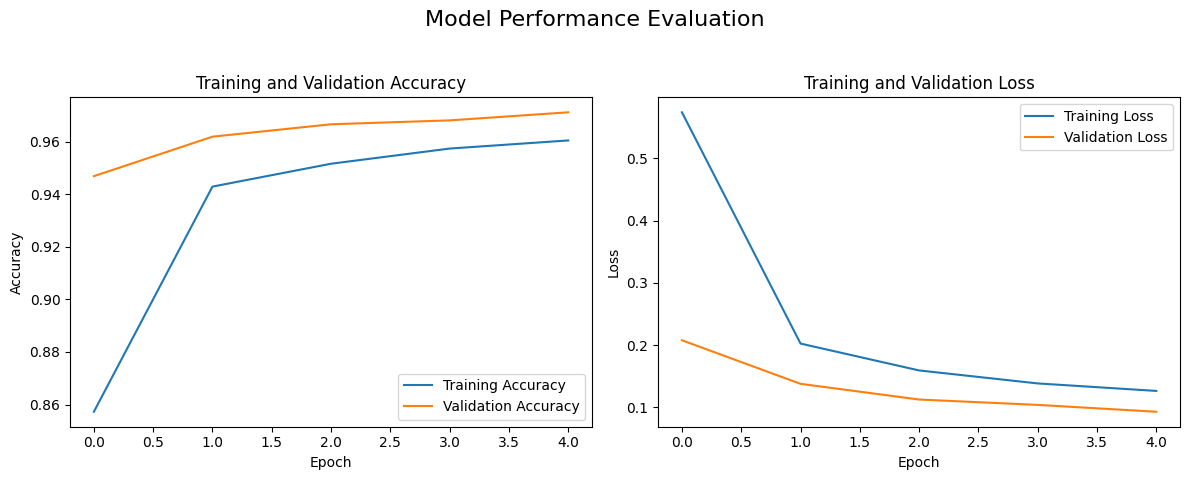


Saving the trained model...
✅ Model saved successfully to: plant_doctor_vision_model.keras
total 4.4M
drwxr-xr-x 5 root root 4.0K Nov 15 05:55 data
-rw-r--r-- 1 root root 4.4M Nov 15 06:40 plant_doctor_vision_model.keras
drwxr-xr-x 1 root root 4.0K Nov 12 14:30 sample_data


In [4]:
# --- Part D: Evaluate and Save the Trained Model ---
import matplotlib.pyplot as plt
import numpy as np

# 1. Visualize Training History
print("Visualizing training and validation performance...")

# Extract accuracy and loss from the 'history' object
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(EPOCHS)

# Create a figure with two subplots
plt.figure(figsize=(12, 5))

# Subplot 1: Training and Validation Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

# Subplot 2: Training and Validation Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

# Show the plots
plt.suptitle('Model Performance Evaluation', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# 2. Save the Model
print("\nSaving the trained model...")
# We will save the model in the recommended Keras v3 format (.keras)
model_save_path = "plant_doctor_vision_model.keras"
model.save(model_save_path)

print(f"✅ Model saved successfully to: {model_save_path}")

# To confirm, let's list the files in the current directory
!ls -lh

In [5]:
# --- Part E: Convert the Model to TensorFlow Lite ---
import tensorflow as tf

# 1. Load the Keras model we just saved
model_path = "plant_doctor_vision_model.keras"
print(f"Loading the saved model from: {model_path}")
model = tf.keras.models.load_model(model_path)

# 2. Create a TFLite Converter object
converter = tf.lite.TFLiteConverter.from_keras_model(model)

# 3. Apply optimizations (Float16 Quantization)
# This is a great optimization that reduces model size by almost half
# with a negligible impact on accuracy.
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_types = [tf.float16]

# 4. Perform the conversion
print("\nConverting the model to TensorFlow Lite with Float16 quantization...")
tflite_model = converter.convert()
print("Conversion successful.")

# 5. Save the TFLite model to a file
tflite_model_path = "plant_doctor_vision_model.tflite"
with open(tflite_model_path, 'wb') as f:
    f.write(tflite_model)

print(f"\n✅ TensorFlow Lite model saved to: {tflite_model_path}")

# 6. Verify the file sizes
print("\n--- File Size Comparison ---")
!ls -lh plant_doctor_vision_model.keras
!ls -lh plant_doctor_vision_model.tflite

Loading the saved model from: plant_doctor_vision_model.keras

Converting the model to TensorFlow Lite with Float16 quantization...
Saved artifact at '/tmp/tmpr889w3js'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 38), dtype=tf.float32, name=None)
Captures:
  138086037422352: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138086037437520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138086037437328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138086037437136: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138086037438096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138086037436176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138086037436560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138086037437904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138086037437712: Tenso